In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, Normalize

# -----------------------------
# 1) Paste / edit your data here
# -----------------------------
experiments = [
    "Knapsack (Gen)",
    "Knapsack (Energy)",
    "Scheduling (Energy)",
    "Budget Allocation",
    "TopK (Cubic)",
    "Bipartite Matching",
    "Portfolio",
]

# Baseline methods (11) — from your table
baseline_methods = [
    "Two-stage", "DFL", "Blackbox", "Identity", "CPLayer", "SPO",
    "NCE", "point-LTR", "pair-LTR", "list-LTR", "LODL"
]


In [2]:

# Regret table (11 baselines per experiment). Use np.nan where method missing (e.g., CPLayer in some tasks).
regret_data = {
    "Knapsack (Gen)": {
        "Two-stage": 6.595, "DFL": 11.744, "Blackbox": 24.274, "Identity": 31.874,
        "CPLayer": 24.769, "SPO": 6.223, "NCE": 13.438, "point-LTR": 6.402,
        "pair-LTR": 7.820, "list-LTR": 6.031, "LODL": 6.044
    },
    "Knapsack (Energy)": {
        "Two-stage": 8.745, "DFL": 8.353, "Blackbox": 35.705, "Identity": 17.156,
        "CPLayer": 36.402, "SPO": 8.407, "NCE": 11.932, "point-LTR": 8.236,
        "pair-LTR": 9.022, "list-LTR": 8.083, "LODL": 9.567
    },
    "Scheduling (Energy)": {
        "Two-stage": 1.793, "DFL": 6.272, "Blackbox": 6.503, "Identity": 5.690,
        "CPLayer": np.nan, "SPO": 1.505, "NCE": 1.663, "point-LTR": 4.548,
        "pair-LTR": 1.540, "list-LTR": 1.551, "LODL": 1.786
    },
    "Budget Allocation": {
        "Two-stage": 20.332, "DFL": 35.970, "Blackbox": 26.905, "Identity": 14.799,
        "CPLayer": np.nan, "SPO": 5.559, "NCE": 9.979, "point-LTR": 69.663,
        "pair-LTR": 5.958, "list-LTR": 5.742, "LODL": 25.700
    },
    "TopK (Cubic)": {
        "Two-stage": 0.110, "DFL": 1.974, "Blackbox": 13.944, "Identity": 13.944,
        "CPLayer": np.nan, "SPO": 160.408, "NCE": 160.408, "point-LTR": 1.149,
        "pair-LTR": 5.072, "list-LTR": 0.193, "LODL": 0.172
    },
    "Bipartite Matching": {
        "Two-stage": 92.963, "DFL": 91.364, "Blackbox": 91.988, "Identity": 91.868,
        "CPLayer": 92.007, "SPO": 93.327, "NCE": 92.622, "point-LTR": 91.035,
        "pair-LTR": 92.285, "list-LTR": 91.831, "LODL": 91.113
    },
    "Portfolio": {
        "Two-stage": 0.243, "DFL": 0.380, "Blackbox": 0.286, "Identity": 0.280,
        "CPLayer": 0.309, "SPO": 0.245, "NCE": 0.367, "point-LTR": 0.214,
        "pair-LTR": 0.255, "list-LTR": 0.249, "LODL": 0.160
    },
}


In [3]:

# -----------------------------
# 2) Add your DPO regrets here (placeholders)
# -----------------------------
# Put numbers per experiment when you have them.
# Example:
# dpo_naive = {"Knapsack (Gen)": 6.8, ...}
# dpo_tuned = {"Knapsack (Gen)": 6.1, ...}
dpo_naive = {
    "TopK (Cubic)": 1.6,                 # Cubic
    "Budget Allocation": 11.55996995,      # Budget
    "Bipartite Matching": 93.36066397,     # Bipartite
    "Knapsack (Gen)": 20.52870715,         # Knapsack
    "Knapsack (Energy)": 8.297988059,      # Knapsack Energy
    "Portfolio": 1014.157119,              # Portfolio
}
dpo_tuned = {
    "TopK (Cubic)": 0.130,                 # Cubic
    }  # <-- fill these


dpo_naive = {
    "TopK (Cubic)": 13.613,                 # Cubic
    "Budget Allocation": 3.171688507,      # Budget
    "Bipartite Matching": 91.20252343,     # Bipartite
    "Knapsack (Gen)": 9.858185323,         # Knapsack
    "Knapsack (Energy)":8.529747148,      # Knapsack Energy
    "Portfolio": 0.3514,              # Portfolio
    "Scheduling (Energy)": 2.243905856
}
dpo_tuned = {
    "TopK (Cubic)": 0.218,                 # Cubic
    #"Knapsack (Gen)": 9.858185323,         # Knapsack
    "Portfolio": 0.2548,              # Portfolio
    "Scheduling (Energy)": 2.278,
    "Knapsack (Gen)": 11.442,         # Knapsack
    }  # <-- fill these
mse_tuned = {
    "Knapsack (Gen)": 5.4,         # Knapsack
    "Knapsack (Energy)": 7.2,      # Knapsack Energy    
    "Scheduling (Energy)": 1.95,     # Scheduling Energy
    "Budget Allocation": 36.6,      # Budget
    "TopK (Cubic)": 0.02,                 # Cubic
    "Bipartite Matching": 91.7,     # Bipartite
    "Portfolio": 0.221,              # Portfolio
}


Saved: dpo_regret_rank_tableplot.pdf


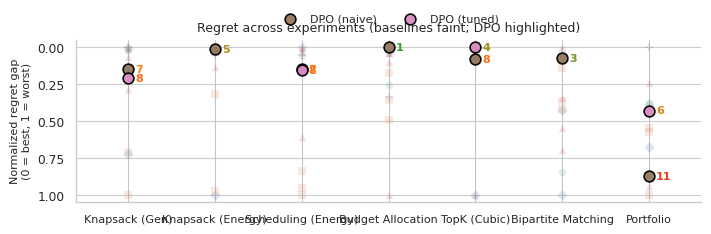

In [4]:

# -----------------------------
# 3) Family -> marker mapping
# -----------------------------
family_of = {
    "Two-stage": "Predictive",
    "DFL": "Discrete",
    "Blackbox": "Discrete",
    "Identity": "Discrete",
    "CPLayer": "Continuous",
    "SPO": "Continuous",
    "NCE": "Statistical",
    "point-LTR": "Statistical",
    "pair-LTR": "Statistical",
    "list-LTR": "Statistical",
    "LODL": "Surrogate",
    "DPO": "Discrete",
}

marker_of_family = {
    "Predictive": "o",
    "Discrete": "s",
    "Continuous": "D",
    "Statistical": "^",
    "Surrogate": "P",
}

# -----------------------------
# 4) Build a tidy dataframe with baselines + DPO (naive/tuned)
# -----------------------------
rows = []
for exp in experiments:
    for m in baseline_methods:
        val = regret_data[exp].get(m, np.nan)
        rows.append({
            "experiment": exp,
            "method": m,
            "variant": "baseline",
            "regret": val,
            "family": family_of[m],
        })
    # DPO entries
    rows.append({
        "experiment": exp,
        "method": "DPO",
        "variant": "DPO (naive)",
        "regret": dpo_naive.get(exp, np.nan),
        "family": family_of["DPO"],
    })
    rows.append({
        "experiment": exp,
        "method": "DPO",
        "variant": "DPO (tuned)",
        "regret": dpo_tuned.get(exp, np.nan),
        "family": family_of["DPO"],
    })

df = pd.DataFrame(rows)

# -----------------------------
# 5) Compute within-experiment normalized gap AND rank
# -----------------------------
df["rank"] = np.nan
df["gap"] = np.nan
for exp_name in experiments:
    mask = df["experiment"] == exp_name
    # rank (dense, ascending: 1 = best / lowest regret)
    df.loc[mask, "rank"] = df.loc[mask, "regret"].rank(method="dense", ascending=True)
    # normalized gap (0 = best, 1 = worst)
    vals = df.loc[mask, "regret"].to_numpy(dtype=float)
    finite = np.isfinite(vals)
    if finite.sum() >= 2:
        rmin, rmax = np.nanmin(vals), np.nanmax(vals)
        denom = rmax - rmin
        if denom > 0:
            df.loc[mask, "gap"] = (df.loc[mask, "regret"] - rmin) / denom
        else:
            df.loc[mask, "gap"] = 0.0

df["y"] = df["gap"]  # plot the normalized gap

# -----------------------------
# 6) Plot
# -----------------------------
sns.set_theme(style="whitegrid", context="paper")

fig_w = 7.2   # inches -- fits a 2-column paper width
fig_h = 2.5
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# x positions (one per experiment)
x_map = {exp: i for i, exp in enumerate(experiments)}
df["x"] = df["experiment"].map(x_map)

# Baselines: faint, marker by family, no labels
baseline = df[df["variant"] == "baseline"].copy()
for fam, fam_df in baseline.groupby("family"):
    fam_df = fam_df.dropna(subset=["regret", "y"])
    ax.scatter(
        fam_df["x"], fam_df["y"],
        s=28,
        marker=marker_of_family.get(fam, "o"),
        alpha=0.18,
        linewidths=0.0,
        zorder=2,
    )

# DPO points: two variants, higher opacity + outline
dpo = df[df["variant"].str.contains("DPO")].copy()

# Rank label colormap: green (1) -> orange -> red (13)
cmap = LinearSegmentedColormap.from_list("rank_g2r", ["#2ca02c", "#ff7f0e", "#d62728"])
norm = Normalize(vmin=1, vmax=13)

for variant_name, sub in dpo.groupby("variant"):
    sub = sub.dropna(subset=["regret", "y"])
    ax.scatter(
        sub["x"], sub["y"],
        s=60,
        marker="o",
        alpha=0.95,
        linewidths=1.2,
        edgecolors="black",
        zorder=4,
        label=variant_name,
    )
    # Rank labels colored green->red
    for _, r in sub.iterrows():
        rank = int(r["rank"]) if np.isfinite(r["rank"]) else None
        if rank is None:
            continue
        ax.text(
            r["x"] + 0.08, r["y"],
            f"{rank}",
            va="center", ha="left",
            fontsize=8,
            fontweight="bold",
            color=cmap(norm(rank)),
            zorder=5,
        )

# Axes formatting
ax.set_xlim(-0.6, len(experiments) - 0.4)
ax.set_ylim(1.05, -0.05)  # 0 (best) at bottom, 1 (worst) at top
ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
ax.set_ylabel("Normalized regret gap\n(0 = best, 1 = worst)", fontsize=8)
ax.set_xlabel("")

ax.set_xticks(range(len(experiments)))
ax.set_xticklabels(experiments, rotation=0, fontsize=8)

# Light separators between experiments
for i in range(len(experiments)):
    ax.axvline(i, ymin=0.03, ymax=0.97, linewidth=0.5, alpha=0.12, zorder=1)

# Legend for DPO variants only
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.22),
              ncol=2, frameon=False, fontsize=8)

ax.set_title("Regret across experiments (baselines faint; DPO highlighted)", fontsize=9, pad=6)
sns.despine(ax=ax, left=False, bottom=False)
plt.tight_layout()

# Save for LaTeX
out_path = "dpo_regret_rank_tableplot.pdf"
plt.savefig(out_path, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()


In [20]:
df

,experiment,method,variant,regret,family,rank,gap,y,x
0,Knapsack (Gen),Two-stage,baseline,6.5950,Predictive,5.0,0.021824,0.021824,0
1,Knapsack (Gen),DFL,baseline,11.7440,Discrete,9.0,0.221066,0.221066,0
2,Knapsack (Gen),Blackbox,baseline,24.2740,Discrete,11.0,0.705916,0.705916,0
3,Knapsack (Gen),Identity,baseline,31.8740,Discrete,13.0,1.000000,1.000000,0
4,Knapsack (Gen),CPLayer,baseline,24.7690,Continuous,12.0,0.725071,0.725071,0
...,...,...,...,...,...,...,...,...,...
86,Portfolio,pair-LTR,baseline,0.2550,Statistical,7.0,0.431818,0.431818,6
87,Portfolio,list-LTR,baseline,0.2490,Statistical,5.0,0.404545,0.404545,6
88,Portfolio,LODL,baseline,0.1600,Surrogate,1.0,0.000000,0.000000,6
89,Portfolio,DPO,DPO (naive),0.3514,Discrete,11.0,0.870000,0.870000,6


Saved: dpo_rank_heatmap.pdf


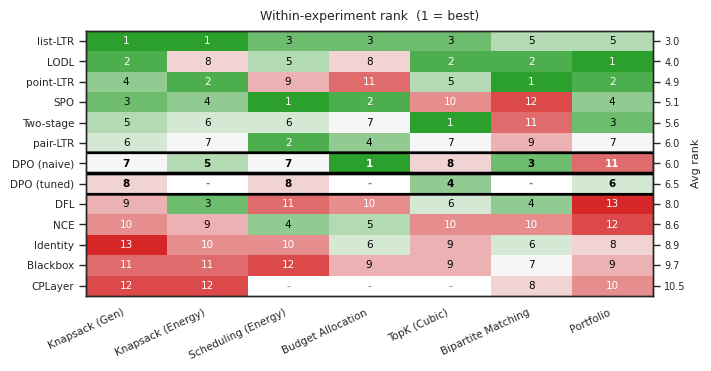

In [21]:
# =====================================================================
# PLOT A: Rank Heatmap Table
# Rows = methods (sorted by average rank), Columns = experiments
# Cell color encodes rank; DPO rows outlined in black
# =====================================================================
import matplotlib.patches as mpatches

all_methods_A = baseline_methods + ["DPO (naive)", "DPO (tuned)"]

# Build raw regret matrix
regret_matrix = pd.DataFrame(index=all_methods_A, columns=experiments, dtype=float)
for exp in experiments:
    for m in baseline_methods:
        regret_matrix.loc[m, exp] = regret_data[exp].get(m, np.nan)
    regret_matrix.loc["DPO (naive)", exp] = dpo_naive.get(exp, np.nan)
    regret_matrix.loc["DPO (tuned)", exp] = dpo_tuned.get(exp, np.nan)

# Convert raw regret to within-column rank
rank_only = regret_matrix.copy()
for exp in experiments:
    rank_only[exp] = regret_matrix[exp].rank(method="dense", ascending=True)

# Sort rows by average rank (best on top)
rank_only["avg_rank"] = rank_only[experiments].mean(axis=1)
rank_only = rank_only.sort_values("avg_rank")
avg_ranks = rank_only["avg_rank"].copy()
rank_only = rank_only.drop(columns="avg_rank")

sns.set_theme(style="white", context="paper")
fig, ax = plt.subplots(figsize=(7.2, 3.8))

# Custom green-white-red colormap (rank 1=green, worst=red)
cmap_heat = LinearSegmentedColormap.from_list(
    "gwr", ["#2ca02c", "#f7f7f7", "#d62728"]
)
max_rank = float(np.nanmax(rank_only.values))

im = ax.imshow(
    rank_only.values.astype(float),
    aspect="auto",
    cmap=cmap_heat,
    vmin=1,
    vmax=max_rank,
    interpolation="nearest",
)

# Annotate each cell with rank number
for i, method in enumerate(rank_only.index):
    for j, exp_col in enumerate(rank_only.columns):
        val = rank_only.loc[method, exp_col]
        if np.isnan(val):
            txt = "-"
            color = "gray"
        else:
            txt = f"{int(val)}"
            color = "white" if val > max_rank * 0.7 or val < max_rank * 0.2 else "black"
        ax.text(j, i, txt, ha="center", va="center", fontsize=7.5, color=color,
                fontweight="bold" if "DPO" in method else "normal")

# Highlight DPO rows with a thick rectangle
for i, method in enumerate(rank_only.index):
    if "DPO" in method:
        rect = mpatches.FancyBboxPatch(
            (-0.5, i - 0.5), len(experiments), 1,
            boxstyle="round,pad=0.02",
            linewidth=2.0, edgecolor="black", facecolor="none",
            zorder=5,
        )
        ax.add_patch(rect)

# Axes
ax.set_xticks(range(len(experiments)))
ax.set_xticklabels(experiments, fontsize=7.5, rotation=25, ha="right")
ax.set_yticks(range(len(rank_only)))
ax.set_yticklabels(rank_only.index, fontsize=7.5)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Within-experiment rank  (1 = best)", fontsize=9, pad=8)

# Add average rank on the right
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(range(len(rank_only)))
ax2.set_yticklabels([f"{v:.1f}" for v in avg_ranks[rank_only.index]], fontsize=7)
ax2.set_ylabel("Avg rank", fontsize=8)

plt.tight_layout()
plt.savefig("dpo_rank_heatmap.pdf", bbox_inches="tight")
print("Saved: dpo_rank_heatmap.pdf")
plt.show()

Saved: dpo_arrow_ranks_v2.pdf


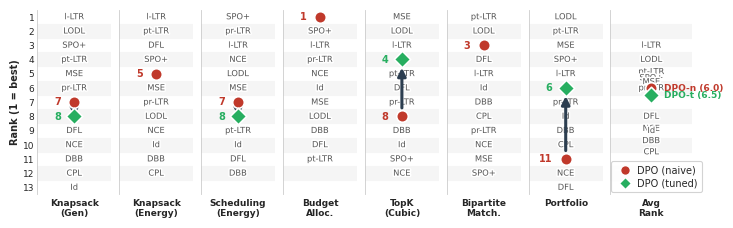

In [22]:
# =====================================================================
# PLOT B2: Polished Arrow/Bump Chart
# =====================================================================
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import matplotlib.patheffects as pe

# Abbreviation map
abbr = {
    "Two-stage": "MSE", "DFL": "DFL", "Blackbox": "DBB",
    "Identity": "Id", "CPLayer": "CPL", "SPO": "SPO+",
    "NCE": "NCE", "point-LTR": "pt-LTR", "pair-LTR": "pr-LTR",
    "list-LTR": "l-LTR", "LODL": "LODL",
    "DPO (naive)": "DPO-n", "DPO (tuned)": "DPO-t",
}

exp_short = {
    "Knapsack (Gen)": "Knapsack\n(Gen)",
    "Knapsack (Energy)": "Knapsack\n(Energy)",
    "Scheduling (Energy)": "Scheduling\n(Energy)",
    "Budget Allocation": "Budget\nAlloc.",
    "TopK (Cubic)": "TopK\n(Cubic)",
    "Bipartite Matching": "Bipartite\nMatch.",
    "Portfolio": "Portfolio",
}

all_methods_B = baseline_methods + ["DPO (naive)", "DPO (tuned)"]
n_exp = len(experiments)

# Build regret matrix
regret_mat_B = pd.DataFrame(index=all_methods_B, columns=experiments, dtype=float)
for exp in experiments:
    for m in baseline_methods:
        regret_mat_B.loc[m, exp] = regret_data[exp].get(m, np.nan)
    regret_mat_B.loc["DPO (naive)", exp] = dpo_naive.get(exp, np.nan)
    regret_mat_B.loc["DPO (tuned)", exp] = dpo_tuned.get(exp, np.nan)

# Position rank (unique y per method) and display rank (allows ties)
pos_rank = regret_mat_B.copy()
disp_rank = regret_mat_B.copy()
for exp in experiments:
    pos_rank[exp] = regret_mat_B[exp].rank(method="first", ascending=True)
    disp_rank[exp] = regret_mat_B[exp].rank(method="min", ascending=True)

int_max_r = int(pos_rank.max().max())

# Average ranks
avg_r, avg_pos = {}, {}
for m in all_methods_B:
    fd = [disp_rank.loc[m, e] for e in experiments if np.isfinite(disp_rank.loc[m, e])]
    fp = [pos_rank.loc[m, e] for e in experiments if np.isfinite(pos_rank.loc[m, e])]
    avg_r[m] = np.mean(fd) if fd else np.nan
    avg_pos[m] = np.mean(fp) if fp else np.nan

methods_by_avg = sorted(all_methods_B, key=lambda m: avg_r.get(m, 999))

# ---- Style ----
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": False,
})

DPO_NAIVE_C = "#c0392b"
DPO_TUNED_C = "#27ae60"
ARROW_C     = "#2c3e50"
BASELINE_C  = "#555555"
BAND_C      = "#f5f5f5"

# Wide & short figure for 2-column paper header
fig = plt.figure(figsize=(7.2, 2.4))
gs = GridSpec(1, n_exp + 1, figure=fig,
              width_ratios=[1]*n_exp + [1.1], wspace=0.10)

axes_exp = [fig.add_subplot(gs[0, j]) for j in range(n_exp)]
ax_avg = fig.add_subplot(gs[0, n_exp])

def style_ax(ax, show_ylabel=False):
    ax.set_ylim(int_max_r + 0.5, 0.5)
    ax.set_xlim(-0.45, 0.45)
    ax.set_xticks([])
    for rk in range(1, int_max_r + 1):
        if rk % 2 == 0:
            ax.axhspan(rk - 0.5, rk + 0.5, color=BAND_C, zorder=0)
    if show_ylabel:
        ax.set_yticks(range(1, int_max_r + 1))
        ax.set_ylabel("Rank (1 = best)", fontsize=7, fontweight="bold", labelpad=2)
        ax.tick_params(axis="y", labelsize=6.5, length=0, pad=2)
    else:
        ax.set_yticks(range(1, int_max_r + 1))
        ax.set_yticklabels([])
        ax.tick_params(axis="y", length=0)
    ax.spines["left"].set_linewidth(0.6)
    ax.spines["left"].set_color("#cccccc")

stroke = [pe.withStroke(linewidth=2.2, foreground="white")]

# ---- Per-experiment columns ----
for j, exp in enumerate(experiments):
    ax = axes_exp[j]
    style_ax(ax, show_ylabel=(j == 0))

    for m in baseline_methods:
        ypos = pos_rank.loc[m, exp]
        if np.isnan(ypos):
            continue
        ax.text(0, ypos, abbr.get(m, m), va="center", ha="center",
                fontsize=6.0, color=BASELINE_C, fontweight="medium",
                path_effects=stroke, zorder=3)

    y_naive = pos_rank.loc["DPO (naive)", exp]
    y_tuned = pos_rank.loc["DPO (tuned)", exp]
    d_naive = disp_rank.loc["DPO (naive)", exp]
    d_tuned = disp_rank.loc["DPO (tuned)", exp]

    if np.isfinite(y_naive) and np.isfinite(y_tuned):
        ax.annotate(
            "", xy=(0, y_tuned), xytext=(0, y_naive),
            arrowprops=dict(arrowstyle="-|>", color=ARROW_C, lw=2.2,
                            shrinkA=6, shrinkB=6, mutation_scale=12),
            zorder=4,
        )

    if np.isfinite(y_naive):
        ax.scatter(0, y_naive, s=70, color=DPO_NAIVE_C, edgecolors="white",
                   linewidths=1.2, zorder=6, marker="o")
        ax.text(-0.16, y_naive, f"{int(d_naive)}", va="center", ha="right",
                fontsize=7, color=DPO_NAIVE_C, fontweight="bold", zorder=7)

    if np.isfinite(y_tuned):
        ax.scatter(0, y_tuned, s=70, color=DPO_TUNED_C, edgecolors="white",
                   linewidths=1.2, zorder=6, marker="D")
        ax.text(-0.16, y_tuned, f"{int(d_tuned)}", va="center", ha="right",
                fontsize=7, color=DPO_TUNED_C, fontweight="bold", zorder=7)

    ax.set_xlabel(exp_short.get(exp, exp), fontsize=6.5, fontweight="bold", labelpad=3)

# ---- Average Rank column ----
style_ax(ax_avg, show_ylabel=False)
for m in methods_by_avg:
    ar, ap = avg_r[m], avg_pos[m]
    if np.isnan(ar):
        continue
    is_dpo = "DPO" in m
    if is_dpo:
        c = DPO_NAIVE_C if m == "DPO (naive)" else DPO_TUNED_C
        mkr = "o" if m == "DPO (naive)" else "D"
        ax_avg.scatter(0, ap, s=70, marker=mkr, color=c,
                       edgecolors="white", linewidths=1.2, zorder=6)
        ax_avg.text(0.14, ap, f"{abbr[m]} ({ar:.1f})", va="center", ha="left",
                    fontsize=6.5, color=c, fontweight="bold", zorder=7)
    else:
        ax_avg.text(0, ap, abbr.get(m, m), va="center", ha="center",
                    fontsize=6.0, color=BASELINE_C, fontweight="medium",
                    path_effects=stroke, zorder=3)

ax_avg.set_xlabel("Avg\nRank", fontsize=6.5, fontweight="bold", labelpad=3)

# Legend — inline at top-right, no suptitle to save vertical space
legend_els = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor=DPO_NAIVE_C,
           markeredgecolor="white", markersize=7, markeredgewidth=1.0,
           label="DPO (naive)"),
    Line2D([0],[0], marker="D", color="w", markerfacecolor=DPO_TUNED_C,
           markeredgecolor="white", markersize=6, markeredgewidth=1.0,
           label="DPO (tuned)"),
]
fig.legend(handles=legend_els, loc="lower right", bbox_to_anchor=(0.99, 0.17),
           ncol=1, frameon=True, framealpha=0.85, edgecolor="#cccccc",
           fontsize=7, handletextpad=0.3, borderpad=0.4, labelspacing=0.3)

plt.subplots_adjust(top=0.95, bottom=0.18, left=0.06, right=0.97)
plt.savefig("dpo_arrow_ranks_v2.pdf", bbox_inches="tight", dpi=300)
print("Saved: dpo_arrow_ranks_v2.pdf")
plt.show()

Saved: dpo_faceted_lollipop.pdf


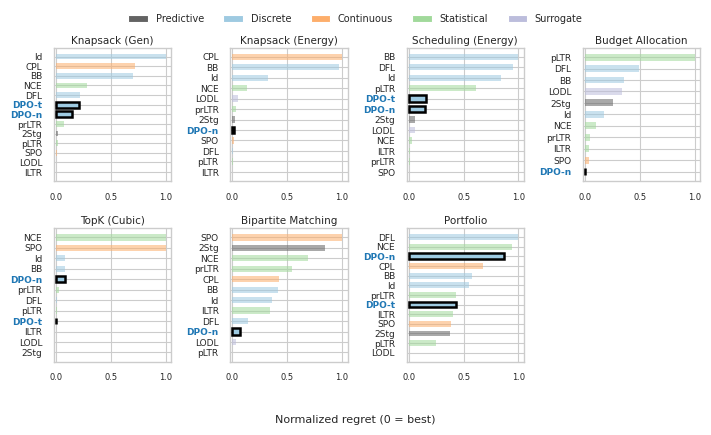

In [23]:
# =====================================================================
# PLOT C: Faceted horizontal lollipop  --  one panel per experiment
# Methods on y-axis sorted by regret, bars/dots colored by family,
# DPO variants highlighted with bold outlines and labels.
# =====================================================================

# Abbreviation map for compact y-labels
abbrev = {
    "Two-stage": "2Stg", "DFL": "DFL", "Blackbox": "BB",
    "Identity": "Id", "CPLayer": "CPL", "SPO": "SPO",
    "NCE": "NCE", "point-LTR": "pLTR", "pair-LTR": "prLTR",
    "list-LTR": "lLTR", "LODL": "LODL",
    "DPO (naive)": "DPO-n", "DPO (tuned)": "DPO-t",
}

family_color = {
    "Predictive": "#636363",
    "Discrete":   "#9ecae1",
    "Continuous":  "#fdae6b",
    "Statistical": "#a1d99b",
    "Surrogate":   "#bcbddc",
}

family_of_ext = {**family_of}
family_of_ext["DPO (naive)"] = "Discrete"
family_of_ext["DPO (tuned)"] = "Discrete"

n_exp = len(experiments)
ncols = min(n_exp, 4)
nrows = int(np.ceil(n_exp / ncols))

sns.set_theme(style="whitegrid", context="paper")
fig, axes = plt.subplots(nrows, ncols, figsize=(7.2, nrows * 2.0), sharey=False)
axes_flat = np.array(axes).ravel()

for idx, exp in enumerate(experiments):
    ax = axes_flat[idx]

    # Gather regrets
    vals = {}
    for m in baseline_methods:
        v = regret_data[exp].get(m, np.nan)
        if np.isfinite(v):
            vals[m] = v
    v_naive = dpo_naive.get(exp, np.nan)
    if np.isfinite(v_naive):
        vals["DPO (naive)"] = v_naive
    v_tuned = dpo_tuned.get(exp, np.nan)
    if np.isfinite(v_tuned):
        vals["DPO (tuned)"] = v_tuned

    # Normalize 0-1 within experiment
    vmin, vmax = min(vals.values()), max(vals.values())
    denom = vmax - vmin if vmax > vmin else 1.0

    methods_sorted = sorted(vals.keys(), key=lambda m: vals[m])
    y_pos = list(range(len(methods_sorted)))

    for yi, m in enumerate(methods_sorted):
        norm_val = (vals[m] - vmin) / denom
        fam = family_of_ext.get(m, "Discrete")
        c = family_color.get(fam, "#999999")
        is_dpo = "DPO" in m

        ax.barh(yi, norm_val, height=0.6, color=c,
                edgecolor="black" if is_dpo else "none",
                linewidth=1.8 if is_dpo else 0,
                zorder=3 if is_dpo else 2,
                alpha=1.0 if is_dpo else 0.55)

    ax.set_yticks(y_pos)
    ax.set_yticklabels([abbrev.get(m, m) for m in methods_sorted], fontsize=6.5)
    ax.set_xlim(-0.02, 1.05)
    ax.set_title(exp, fontsize=7.5, pad=3)
    ax.tick_params(axis="x", labelsize=6)

    # Bold DPO labels
    for label in ax.get_yticklabels():
        if "DPO" in label.get_text():
            label.set_fontweight("bold")
            label.set_color("#1f77b4")

# Hide unused axes
for idx in range(n_exp, len(axes_flat)):
    axes_flat[idx].set_visible(False)

# Shared x-label
fig.supxlabel("Normalized regret (0 = best)", fontsize=8, y=-0.01)

# Family legend
from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=c, label=f) for f, c in family_color.items()]
fig.legend(handles=legend_patches, loc="upper center",
           bbox_to_anchor=(0.5, 1.04), ncol=5, frameon=False, fontsize=7)

plt.tight_layout()
plt.savefig("dpo_faceted_lollipop.pdf", bbox_inches="tight")
print("Saved: dpo_faceted_lollipop.pdf")
plt.show()

Best avg-rank baseline (excl. SPO): list-LTR  (avg rank 3.71)
Saved: dpo_pct_of_best_arrow_mseasy.pdf


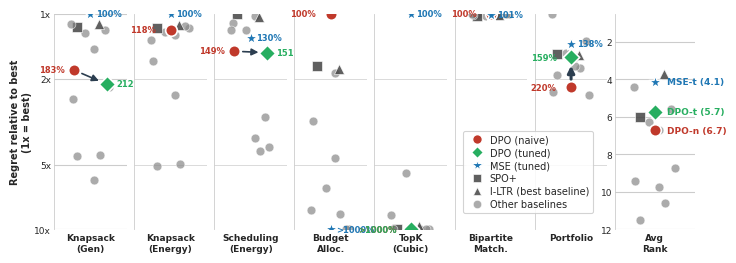

In [8]:

# =====================================================================
# PLOT D: Arrow chart with regret as % of best (log scale, fixed cap)
# Combines arrow style from Plot B2 with regret data
# Y-axis top is always 100% (best); bottom is capped at 1000%
# If MSE (tuned) is <100%, that experiment is rescaled so MSE maps to 100%
# Avg column: shows average rank (1 = best)
# =====================================================================
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import matplotlib.patheffects as pe
import matplotlib.ticker as mticker

# Abbreviation map
abbr = {
    "Two-stage": "MSE", "DFL": "DFL", "Blackbox": "DBB",
    "Identity": "Id", "CPLayer": "CPL", "SPO": "SPO+",
    "NCE": "NCE", "point-LTR": "pt-LTR", "pair-LTR": "pr-LTR",
    "list-LTR": "l-LTR", "LODL": "LODL",
    "DPO (naive)": "DPO-n", "DPO (tuned)": "DPO-t",
    "MSE (tuned)": "MSE-t",
}

exp_short = {
    "Knapsack (Gen)": "Knapsack\n(Gen)",
    "Knapsack (Energy)": "Knapsack\n(Energy)",
    "Scheduling (Energy)": "Scheduling\n(Energy)",
    "Budget Allocation": "Budget\nAlloc.",
    "TopK (Cubic)": "TopK\n(Cubic)",
    "Bipartite Matching": "Bipartite\nMatch.",
    "Portfolio": "Portfolio",
}

all_methods = baseline_methods + ["DPO (naive)", "DPO (tuned)", "MSE (tuned)"]
n_exp = len(experiments)

# Build regret matrix
regret_mat = pd.DataFrame(index=all_methods, columns=experiments, dtype=float)
for exp in experiments:
    for m in baseline_methods:
        regret_mat.loc[m, exp] = regret_data[exp].get(m, np.nan)
    regret_mat.loc["DPO (naive)", exp] = dpo_naive.get(exp, np.nan)
    regret_mat.loc["DPO (tuned)", exp] = dpo_tuned.get(exp, np.nan)
    regret_mat.loc["MSE (tuned)", exp] = mse_tuned.get(exp, np.nan)

# Compute percentage of best (100% = best, higher = worse)
pct_of_best = regret_mat.copy()
for exp in experiments:
    col = regret_mat[exp]
    min_regret = col.min()
    pct_of_best[exp] = 100 * col / min_regret

# MSE tuned percentages vs best baseline per experiment
mse_pct_by_exp = {}
for exp in experiments:
    mse_pct_by_exp[exp] = pct_of_best.loc["MSE (tuned)", exp]

# Per-experiment rescaling: if MSE < 100, map it to 100 and scale others accordingly
scale_by_exp = {}
for exp in experiments:
    mse_pct = mse_pct_by_exp.get(exp, np.nan)
    if np.isfinite(mse_pct) and mse_pct > 0 and mse_pct < 100:
        scale_by_exp[exp] = 100.0 / mse_pct
    else:
        scale_by_exp[exp] = 1.0

# Compute ranks per experiment
rank_mat = regret_mat.copy()
for exp in experiments:
    rank_mat[exp] = regret_mat[exp].rank(method="min", ascending=True)

# --- Inherit rank for tuned if missing ---
for exp in experiments:
    tuned_rank = rank_mat.loc["DPO (tuned)", exp]
    naive_rank = rank_mat.loc["DPO (naive)", exp]
    if not np.isfinite(tuned_rank) and np.isfinite(naive_rank):
        rank_mat.loc["DPO (tuned)", exp] = naive_rank

# Compute average rank across experiments
avg_rank = {}
for m in all_methods:
    ranks = [rank_mat.loc[m, e] for e in experiments if np.isfinite(rank_mat.loc[m, e])]
    avg_rank[m] = np.mean(ranks) if ranks else np.nan

max_avg_rank = max(v for v in avg_rank.values() if np.isfinite(v))

# ---------- Identify best-avg-rank baseline (excluding DPO, SPO, and MSE-tuned) ----------
best_baseline = min(
    (m for m in baseline_methods if m != "SPO" and np.isfinite(avg_rank.get(m, np.nan))),
    key=lambda m: avg_rank[m],
)
print(f"Best avg-rank baseline (excl. SPO): {best_baseline}  (avg rank {avg_rank[best_baseline]:.2f})")

# ---------- Per-method marker / color helpers ----------
DARK_GRAY   = "#444444"   # SPO+ square & best-baseline triangle
BASELINE_C  = "#888888"   # other baselines
MSE_C       = "#1f77b4"   # tuned MSE star

def baseline_style(m):
    """Return (marker, color, size, alpha) for a baseline method."""
    if m == "SPO":
        return "s", DARK_GRAY, 48, 0.85          # dark gray square
    if m == best_baseline:
        return "^", DARK_GRAY, 52, 0.85          # darker gray triangle
    return "o", BASELINE_C, 40, 0.7               # default gray circle

# Experiments where naive & tuned should be horizontally separated
SPREAD_EXPS = {"Knapsack (Gen)", "Scheduling (Energy)"}
SPREAD_DX = 0.20  # half-width of horizontal offset
MSE_X = 0.0       # centered x-position for tuned MSE stars

# Fixed y-axis limits for all columns (log scale): top best at 100, bottom capped at 1000
Y_MIN = 100
Y_MAX = 1000

# ---- Style ----
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": False,
})

DPO_NAIVE_C = "#c0392b"
DPO_TUNED_C = "#27ae60"
ARROW_C     = "#2c3e50"

# Figure setup
fig = plt.figure(figsize=(7.2, 2.8))
gs = GridSpec(1, n_exp + 1, figure=fig,
              width_ratios=[1]*n_exp + [1.1], wspace=0.10)

axes_exp = [fig.add_subplot(gs[0, j]) for j in range(n_exp)]
ax_avg = fig.add_subplot(gs[0, n_exp])

# Random jitter for baselines (fixed seed for reproducibility)
np.random.seed(42)
jitter_x = {m: np.random.uniform(-0.25, 0.25) for m in baseline_methods}

def style_ax(ax, show_ylabel=False, show_ticks=False):
    ax.set_yscale("log")
    ax.set_ylim(Y_MAX, Y_MIN)  # Inverted: 100% (best) at top
    ax.set_xlim(-0.45, 0.45)
    ax.set_xticks([])

    # Set tick locations for log scale - only major ticks, no minor
    ax.yaxis.set_minor_locator(mticker.NullLocator())

    if show_ticks:
        ax.set_yticks([100, 200, 500, 1000])
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/100:.0f}x"))
        ax.tick_params(axis="y", labelsize=6.5, length=0, pad=2)
    else:
        ax.set_yticks([])

    # Add horizontal reference lines at 200% and 500%
    ax.axhline(200, color="#cccccc", linewidth=0.5, linestyle="-", zorder=1)
    ax.axhline(500, color="#cccccc", linewidth=0.5, linestyle="-", zorder=1)

    if show_ylabel:
        ax.set_ylabel("Regret relative to best\n(1x = best)", fontsize=7, fontweight="bold", labelpad=2)
    ax.spines["left"].set_linewidth(0.6)
    ax.spines["left"].set_color("#cccccc")

# ---- Per-experiment columns ----
for j, exp in enumerate(experiments):
    ax = axes_exp[j]
    style_ax(ax, show_ylabel=(j == 0), show_ticks=(j == 0))
    spread = exp in SPREAD_EXPS
    scale = scale_by_exp.get(exp, 1.0)

    # Draw baseline methods with per-method style
    for m in baseline_methods:
        raw_y = pct_of_best.loc[m, exp]
        if np.isnan(raw_y):
            continue
        yval = min(raw_y * scale, Y_MAX)
        xpos = jitter_x[m]
        mkr, col, sz, alp = baseline_style(m)
        ax.scatter(xpos, yval, s=sz, color=col, edgecolors="white",
                   linewidths=0.5, zorder=3, marker=mkr, alpha=alp)

    y_naive_raw = pct_of_best.loc["DPO (naive)", exp]
    y_tuned_raw = pct_of_best.loc["DPO (tuned)", exp]
    y_naive = min(y_naive_raw * scale, Y_MAX) if np.isfinite(y_naive_raw) else np.nan
    y_tuned = min(y_tuned_raw * scale, Y_MAX) if np.isfinite(y_tuned_raw) else np.nan

    # Determine x positions for naive / tuned
    x_naive = -SPREAD_DX if spread else 0.0
    x_tuned = SPREAD_DX if spread else 0.0

    if np.isfinite(y_naive) and np.isfinite(y_tuned):
        # Arrow from naive to tuned — thinner for spread panels
        arrow_lw = 1.2 if spread else 2.2
        ax.annotate(
            "", xy=(x_tuned, y_tuned), xytext=(x_naive, y_naive),
            arrowprops=dict(arrowstyle="-|>", color=ARROW_C, lw=arrow_lw,
                            shrinkA=6, shrinkB=6, mutation_scale=10),
            zorder=4,
        )

    if np.isfinite(y_naive):
        ax.scatter(x_naive, y_naive, s=70, color=DPO_NAIVE_C, edgecolors="white",
                   linewidths=1.2, zorder=6, marker="o")
        label = f">{Y_MAX:.0f}%" if (y_naive_raw * scale) > Y_MAX else f"{y_naive_raw * scale:.0f}%"
        text_x = x_naive - 0.18 if not spread else x_naive - 0.12
        ax.text(text_x, y_naive, label, va="center", ha="right",
                fontsize=6, color=DPO_NAIVE_C, fontweight="bold", zorder=7)

    if np.isfinite(y_tuned):
        ax.scatter(x_tuned, y_tuned, s=70, color=DPO_TUNED_C, edgecolors="white",
                   linewidths=1.2, zorder=6, marker="D")
        label = f">{Y_MAX:.0f}%" if (y_tuned_raw * scale) > Y_MAX else f"{y_tuned_raw * scale:.0f}%"
        text_x = x_tuned - 0.18 if not spread else x_tuned + 0.12
        ha = "right" if not spread else "left"
        ax.text(text_x, y_tuned, label, va="center", ha=ha,
                fontsize=6, color=DPO_TUNED_C, fontweight="bold", zorder=7)

    # MSE tuned marker + percentage label (centered)
    mse_pct_raw = mse_pct_by_exp.get(exp, np.nan)
    if np.isfinite(mse_pct_raw):
        mse_scaled = mse_pct_raw * scale
        mse_plot = min(mse_scaled, Y_MAX)
        ax.scatter(MSE_X, mse_plot, s=95, color=MSE_C, edgecolors="white",
                   linewidths=1.0, zorder=6, marker="*")
        mse_label = f">{Y_MAX:.0f}%" if mse_scaled > Y_MAX else f"{mse_scaled:.0f}%"
        ax.text(MSE_X + 0.07, mse_plot, mse_label, va="center", ha="left",
                fontsize=6, color=MSE_C, fontweight="bold", zorder=7)

    ax.set_xlabel(exp_short.get(exp, exp), fontsize=6.5, fontweight="bold", labelpad=3)

# ---- Average Rank column ----
methods_by_avg = sorted(all_methods, key=lambda m: avg_rank.get(m, 9999))

# Style avg column for rank (linear scale, 1 to max)
ax_avg.set_ylim(max_avg_rank + 0.5, 0.5)  # Inverted: 1 (best) at top
ax_avg.set_xlim(-0.45, 0.45)
ax_avg.set_xticks([])
ax_avg.tick_params(axis="y", labelsize=6.5, length=0, pad=2)
ax_avg.spines["left"].set_linewidth(0.6)
ax_avg.spines["left"].set_color("#cccccc")

for m in methods_by_avg:
    ar = avg_rank[m]
    if np.isnan(ar):
        continue

    if m == "MSE (tuned)":
        ax_avg.scatter(0, ar, s=95, marker="*", color=MSE_C,
                       edgecolors="white", linewidths=1.0, zorder=6)
        ax_avg.text(0.14, ar, f"{abbr[m]} ({ar:.1f})", va="center", ha="left",
                    fontsize=6.5, color=MSE_C, fontweight="bold", zorder=7)
        continue

    is_dpo = "DPO" in m
    if is_dpo:
        c = DPO_NAIVE_C if m == "DPO (naive)" else DPO_TUNED_C
        mkr = "o" if m == "DPO (naive)" else "D"
        ax_avg.scatter(0, ar, s=70, marker=mkr, color=c,
                       edgecolors="white", linewidths=1.2, zorder=6)
        ax_avg.text(0.14, ar, f"{abbr[m]} ({ar:.1f})", va="center", ha="left",
                    fontsize=6.5, color=c, fontweight="bold", zorder=7)
    else:
        xpos = jitter_x.get(m, 0)
        mkr, col, sz, alp = baseline_style(m)
        ax_avg.scatter(xpos, ar, s=sz, color=col, edgecolors="white",
                       linewidths=0.5, zorder=3, marker=mkr, alpha=alp)

ax_avg.set_xlabel("Avg\nRank", fontsize=6.5, fontweight="bold", labelpad=3)

# Legend — now includes SPO+ and best baseline
legend_els = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor=DPO_NAIVE_C,
           markeredgecolor="white", markersize=7, markeredgewidth=1.0,
           label="DPO (naive)"),
    Line2D([0],[0], marker="D", color="w", markerfacecolor=DPO_TUNED_C,
           markeredgecolor="white", markersize=6, markeredgewidth=1.0,
           label="DPO (tuned)"),
    Line2D([0],[0], marker="*", color="w", markerfacecolor=MSE_C,
           markeredgecolor="white", markersize=9, markeredgewidth=0.8,
           label="MSE (tuned)"),
    Line2D([0],[0], marker="s", color="w", markerfacecolor=DARK_GRAY,
           markeredgecolor="white", markersize=6, markeredgewidth=0.5,
           alpha=0.85, label="SPO+"),
    Line2D([0],[0], marker="^", color="w", markerfacecolor=DARK_GRAY,
           markeredgecolor="white", markersize=6, markeredgewidth=0.5,
           alpha=0.85, label=f"{abbr.get(best_baseline, best_baseline)} (best baseline)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor=BASELINE_C,
           markeredgecolor="white", markersize=6, markeredgewidth=0.5,
           alpha=0.7, label="Other baselines"),
]
fig.legend(handles=legend_els, loc="upper right", bbox_to_anchor=(.835, 0.55),
           ncol=1, frameon=True, framealpha=0.85, edgecolor="#cccccc",
           fontsize=7, handletextpad=0.3, borderpad=0.4, labelspacing=0.3)

plt.subplots_adjust(top=0.95, bottom=0.18, left=0.08, right=0.97)
plt.savefig("dpo_pct_of_best_arrow_mseasy.pdf", bbox_inches="tight", dpi=300)
print("Saved: dpo_pct_of_best_arrow_mseasy.pdf")
plt.show()


In [9]:
# Average ranks excluding Budget Allocation
exclude_exp = "Budget Allocation"
use_experiments = [e for e in experiments if e != exclude_exp]

methods_for_rank = baseline_methods + ["DPO (naive)", "DPO (tuned)", "MSE (tuned)"]

regret_excl = pd.DataFrame(index=methods_for_rank, columns=use_experiments, dtype=float)
for exp in use_experiments:
    for m in baseline_methods:
        regret_excl.loc[m, exp] = regret_data[exp].get(m, np.nan)
    regret_excl.loc["DPO (naive)", exp] = dpo_naive.get(exp, np.nan)
    regret_excl.loc["DPO (tuned)", exp] = dpo_tuned.get(exp, np.nan)
    regret_excl.loc["MSE (tuned)", exp] = mse_tuned.get(exp, np.nan)

rank_excl = regret_excl.copy()
for exp in use_experiments:
    rank_excl[exp] = regret_excl[exp].rank(method="min", ascending=True)

avg_rank_excl = rank_excl.mean(axis=1, skipna=True).sort_values()

print(f"Average ranks excluding: {exclude_exp}")
print(avg_rank_excl.to_string(float_format=lambda x: f"{x:.2f}"))

avg_rank_excl

Average ranks excluding: Budget Allocation
MSE (tuned)    3.00
list-LTR       3.83
LODL           3.83
point-LTR      4.50
Two-stage      6.17
SPO            6.67
pair-LTR       7.17
DPO (tuned)    7.50
DPO (naive)    7.67
DFL            8.50
NCE           10.17
Identity      10.33
Blackbox      10.83
CPLayer       11.50


MSE (tuned)     3.000000
list-LTR        3.833333
LODL            3.833333
point-LTR       4.500000
Two-stage       6.166667
SPO             6.666667
pair-LTR        7.166667
DPO (tuned)     7.500000
DPO (naive)     7.666667
DFL             8.500000
NCE            10.166667
Identity       10.333333
Blackbox       10.833333
CPLayer        11.500000
dtype: float64